## Partie 2 : EDA & Analyse des leviers de performance

> **Objectif** : Explorer les données enrichies, mesurer l'impact des markdowns, des périodes de fêtes et du type de magasin sur le CA hebdomadaire, et identifier les segments les plus performants.

---
**Auteur** : Malcom Closse — Marketing Data Analyst  
**Prérequis** : Partie 1 exécutée (`data/processed/retail_master.csv`)  
**Stack** : Python · Pandas · Matplotlib · Seaborn · PostgrSQL

---
## Import & configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    }
)

COLOR_A = "#1D9E75"
COLOR_B = "#3D8EF0"
COLOR_C = "#E8A820"
COLOR_NEG = "#E05C3A"
COLOR_PROMO = "#A07CF5"
COLORS_TYPE = {"A": COLOR_A, "B": COLOR_B, "C": COLOR_C}

FIGURES = os.path.join("..", "outputs", "figures")
TABLES = os.path.join("..", "outputs", "tables")
DB_PATH = os.path.join("..", "data", "processed", "retail.db")

for p in [FIGURES, TABLES]:
    os.makedirs(p, exist_ok=True)


def save_fig(name):
    plt.savefig(os.path.join(FIGURES, name), dpi=150, bbox_inches="tight")


print("Configuration OK")

Configuration OK


---
## Chargement du dataset maître

In [ ]:
MASTER = os.path.join("..", "data", "processed", "retail_master.csv")
df = pd.read_csv(MASTER, parse_dates=["date"])

# Restaurer les types
df["sizecategory"] = pd.Categorical(
    df["sizecategory"], categories=["Small", "Medium", "Large"], ordered=True
)
MONTH_ORDER = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]
df["monthname"] = pd.Categorical(df["monthname"], categories=MONTH_ORDER, ordered=True)

print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Plage          : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"   CA total       : {df['weeklysalesclean'].sum():,.0f} €")
df.head(3)

 Dataset chargé : 156,000 lignes × 43 colonnes
   Plage          : 2022-01-01 → 2024-12-21
   CA total       : 8,814,544,253 €


,storeid,deptid,date,weeklysales,isholiday,storetype,storesize,region,temperature,fuelprice,...,year,month,week,quarter,monthname,dayname,sizecategory,totalmarkdown,hasmarkdown,markdownsegment
0,1,1,2022-01-01,119075.96,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
1,1,2,2022-01-01,119107.85,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
2,1,3,2022-01-01,84369.88,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte


---
## Vue d'ensemble — KPI globaux & distribution du CA

In [7]:
# KPI globaux
kpis = {
    "CA total": f"{df['weeklysalesclean'].sum():>15,.0f} €",
    "CA moyen / semaine": f"{df['weeklysalesclean'].mean():>15,.2f} €",
    "CA médian / semaine": f"{df['weeklysalesclean'].median():>15,.2f} €",
    "CA max / semaine": f"{df['weeklysalesclean'].max():>15,.2f} €",
    "Nb stores": f"{df['storeid'].nunique():>15}",
    "Nb départements": f"{df['deptid'].nunique():>15}",
    "Nb semaines": f"{df['date'].nunique():>15}",
    "Pct semaines fériées": f"{df['isholiday'].mean() * 100:>14.1f}%",
    "Pct avec MarkDown": f"{df['hasmarkdown'].mean() * 100:>14.1f}%",
}

print("  KPI GLOBAUX")
for k, v in kpis.items():
    print(f"  {k:<28} {v}")

  KPI GLOBAUX
  CA total                       8,814,544,253 €
  CA moyen / semaine                 56,503.49 €
  CA médian / semaine                43,394.87 €
  CA max / semaine                  505,958.73 €
  Nb stores                                 50
  Nb départements                           20
  Nb semaines                              156
  Pct semaines fériées                   11.5%
  Pct avec MarkDown                     100.0%


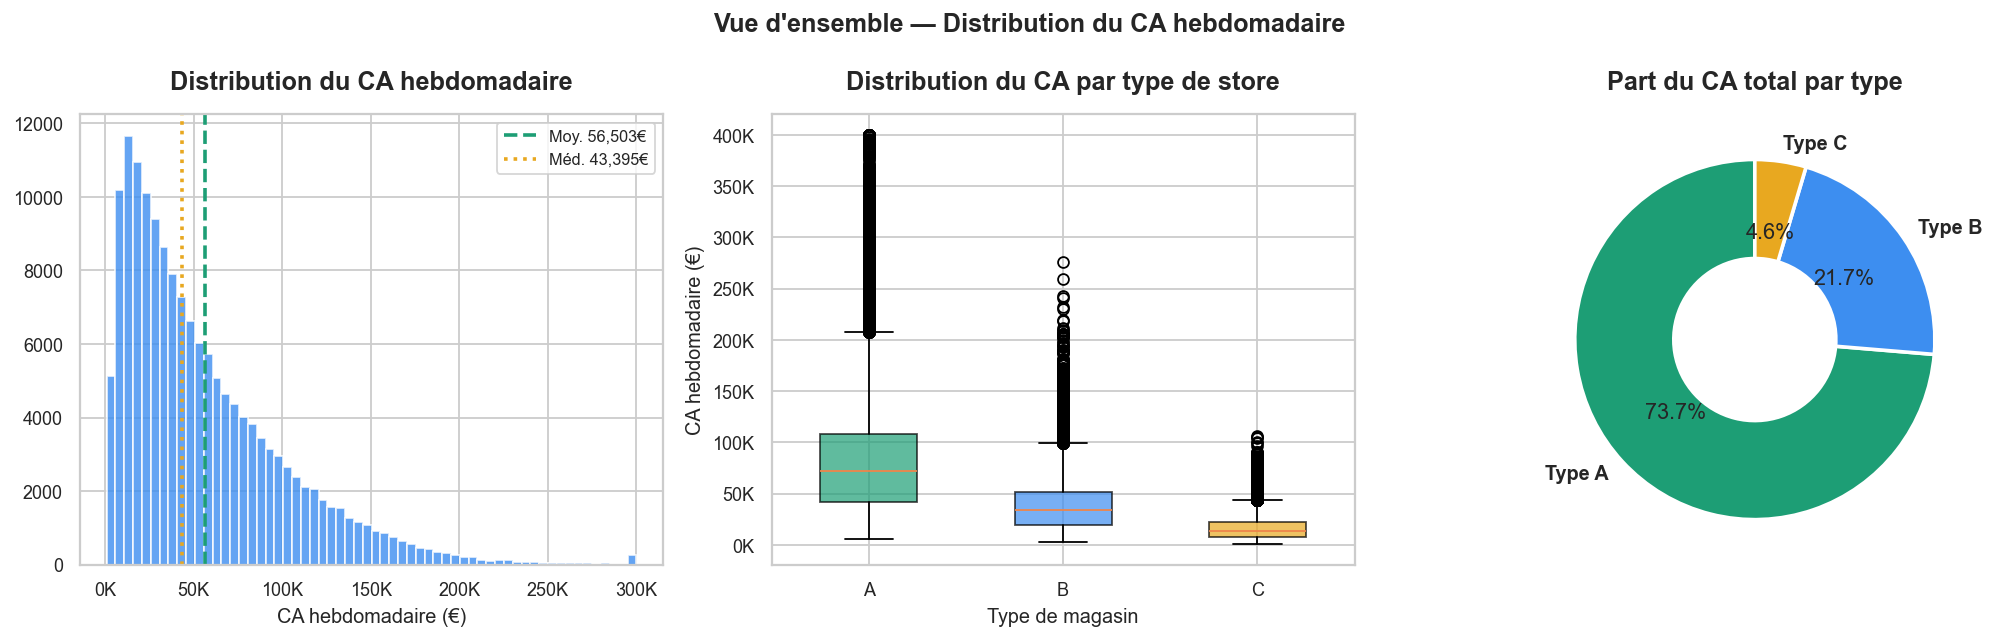

In [ ]:
# Distribution du CA hebdomadaire
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogramme global
axes[0].hist(
    df["weeklysalesclean"].clip(0, 300_000),
    bins=60,
    color=COLOR_B,
    alpha=0.8,
    edgecolor="white",
)
axes[0].axvline(
    df["weeklysalesclean"].mean(),
    color=COLOR_A,
    linewidth=2,
    linestyle="--",
    label=f"Moy. {df['weeklysalesclean'].mean():,.0f}€",
)
axes[0].axvline(
    df["weeklysalesclean"].median(),
    color=COLOR_C,
    linewidth=2,
    linestyle=":",
    label=f"Méd. {df['weeklysalesclean'].median():,.0f}€",
)
axes[0].set_title("Distribution du CA hebdomadaire")
axes[0].set_xlabel("CA hebdomadaire (€)")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x / 1000)}K"))
axes[0].legend(fontsize=9)

# Boxplot par type de store
data_box = [
    df[df["storetype"] == t]["weeklysalesclean"].clip(0, 400_000)
    for t in sorted(df["storetype"].unique())
]
bp = axes[1].boxplot(
    data_box, patch_artist=True, labels=sorted(df["storetype"].unique()), widths=0.5
)
for patch, color in zip(bp["boxes"], [COLOR_A, COLOR_B, COLOR_C]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Distribution du CA par type de store")
axes[1].set_ylabel("CA hebdomadaire (€)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y / 1000)}K"))
axes[1].set_xlabel("Type de magasin")

# CA total par type (camembert)
ca_type = df.groupby("storetype")["weeklysalesclean"].sum().sort_values(ascending=False)
wedges, texts, autotexts = axes[2].pie(
    ca_type.values,
    labels=[f"Type {t}" for t in ca_type.index],
    colors=[COLORS_TYPE.get(t, COLOR_NEG) for t in ca_type.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2),
)
for t in texts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
axes[2].set_title("Part du CA total par type")

plt.suptitle(
    "Vue d'ensemble — Distribution du CA hebdomadaire", fontsize=14, fontweight="bold"
)
plt.tight_layout()
save_fig("02_distribution_ca.png")
plt.show()

---
## Analyse de la saisonnalité

> Quel est le rythme du CA au fil des semaines et des mois ?

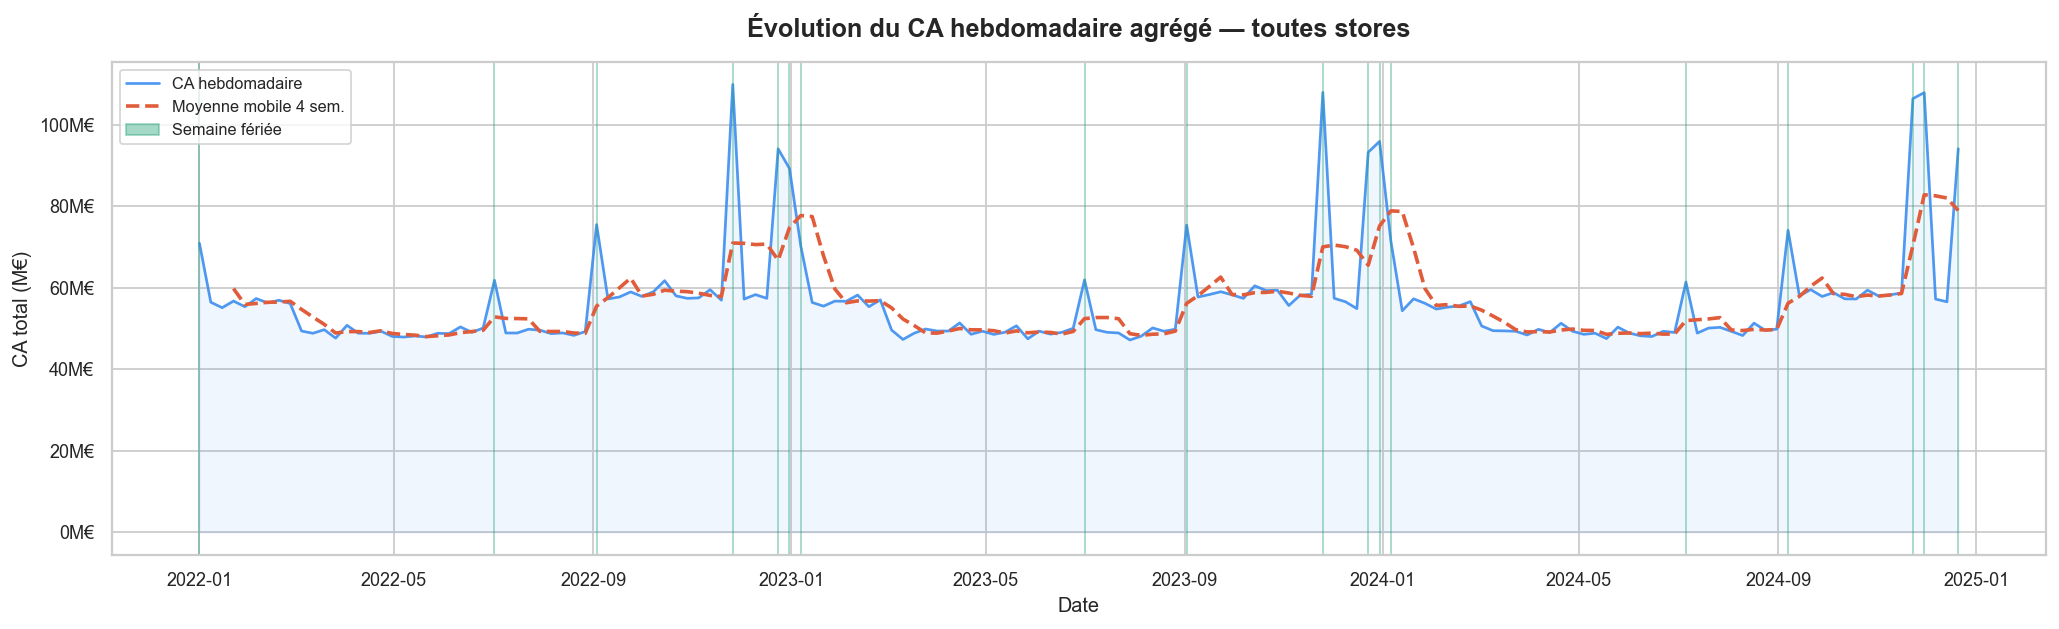

Nombre de semaines fériées : 18
Dates fériées : ['2022-01-01', '2022-07-02', '2022-09-03', '2022-11-26', '2022-12-24', '2022-12-31', '2023-01-07', '2023-07-01', '2023-09-02', '2023-11-25', '2023-12-23', '2023-12-30', '2024-01-06', '2024-07-06', '2024-09-07', '2024-11-23', '2024-11-30', '2024-12-21']


In [9]:
# CA hebdomadaire agrégé (toutes stores)
ca_weekly = (
    df.groupby("date")["weeklysalesclean"].sum().reset_index().sort_values("date")
)

# Identifier les semaines fériées
holidays = df[df["isholiday"] == 1]["date"].unique()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    ca_weekly["date"],
    ca_weekly["weeklysalesclean"] / 1e6,
    color=COLOR_B,
    linewidth=1.5,
    alpha=0.9,
    label="CA hebdomadaire",
)
ax.fill_between(
    ca_weekly["date"], ca_weekly["weeklysalesclean"] / 1e6, alpha=0.08, color=COLOR_B
)

# Marquer les semaines fériées
for h in holidays:
    ax.axvline(pd.to_datetime(h), color=COLOR_A, alpha=0.4, linewidth=1)

# Ligne de moyenne mobile 4 semaines
ca_weekly["ma4"] = ca_weekly["weeklysalesclean"].rolling(4).mean()
ax.plot(
    ca_weekly["date"],
    ca_weekly["ma4"] / 1e6,
    color=COLOR_NEG,
    linewidth=2,
    linestyle="--",
    label="Moyenne mobile 4 sem.",
)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{y:.0f}M€"))
ax.set_xlabel("Date")
ax.set_ylabel("CA total (M€)")
ax.set_title("Évolution du CA hebdomadaire agrégé — toutes stores")

from matplotlib.patches import Patch

legend_extra = Patch(color=COLOR_A, alpha=0.4, label="Semaine fériée")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [legend_extra], labels + ["Semaine fériée"], fontsize=9)

plt.tight_layout()
save_fig("03_ca_hebdomadaire.png")
plt.show()

print(f"Nombre de semaines fériées : {len(holidays)}")
print(f"Dates fériées : {sorted([str(pd.to_datetime(h).date()) for h in holidays])}")

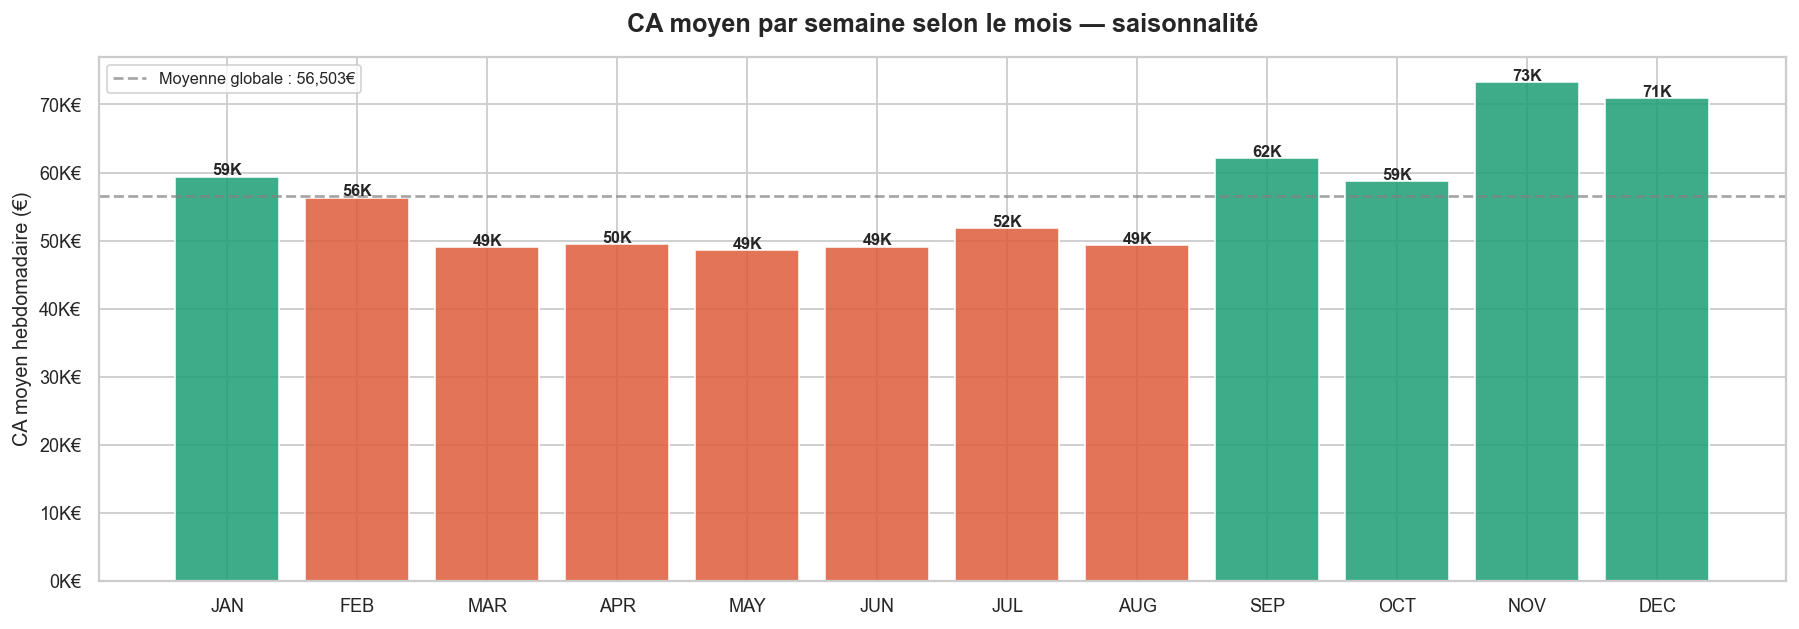

 Meilleur mois : November
 Pire mois    : May


In [ ]:
# CA moyen par mois (saisonnalité)
ca_month = (
    df.groupby(["year", "month", "monthname"], observed=True)
    .agg(ca_total=("weeklysalesclean", "sum"), ca_moyen=("weeklysalesclean", "mean"))
    .reset_index()
)

ca_month_avg = (
    df.groupby("monthname", observed=True)["weeklysalesclean"]
    .mean()
    .reset_index()
    .sort_values("monthname")
)

global_mean = df["weeklysalesclean"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    range(len(ca_month_avg)),
    ca_month_avg["weeklysalesclean"],
    color=[
        COLOR_A if v > global_mean else COLOR_NEG
        for v in ca_month_avg["weeklysalesclean"]
    ],
    alpha=0.85,
    edgecolor="white",
)

ax.axhline(
    global_mean,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label=f"Moyenne globale : {global_mean:,.0f}€",
)

for bar, val in zip(bars, ca_month_avg["weeklysalesclean"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{val / 1000:.0f}K",
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticks(range(len(ca_month_avg)))
ax.set_xticklabels([m[:3].upper() for m in ca_month_avg["monthname"]], fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y / 1000)}K€"))
ax.set_title("CA moyen par semaine selon le mois — saisonnalité")
ax.set_ylabel("CA moyen hebdomadaire (€)")
ax.legend(fontsize=9)

plt.tight_layout()
save_fig("04_saisonnalite_mensuelle.png")
plt.show()

best_month = ca_month_avg.loc[ca_month_avg["weeklysalesclean"].idxmax(), "monthname"]
worst_month = ca_month_avg.loc[ca_month_avg["weeklysalesclean"].idxmin(), "monthname"]
print(f" Meilleur mois : {best_month}")
print(f" Pire mois    : {worst_month}")

---
## Impact des semaines fériées

> Les semaines de fêtes sur-performent-elles réellement ?

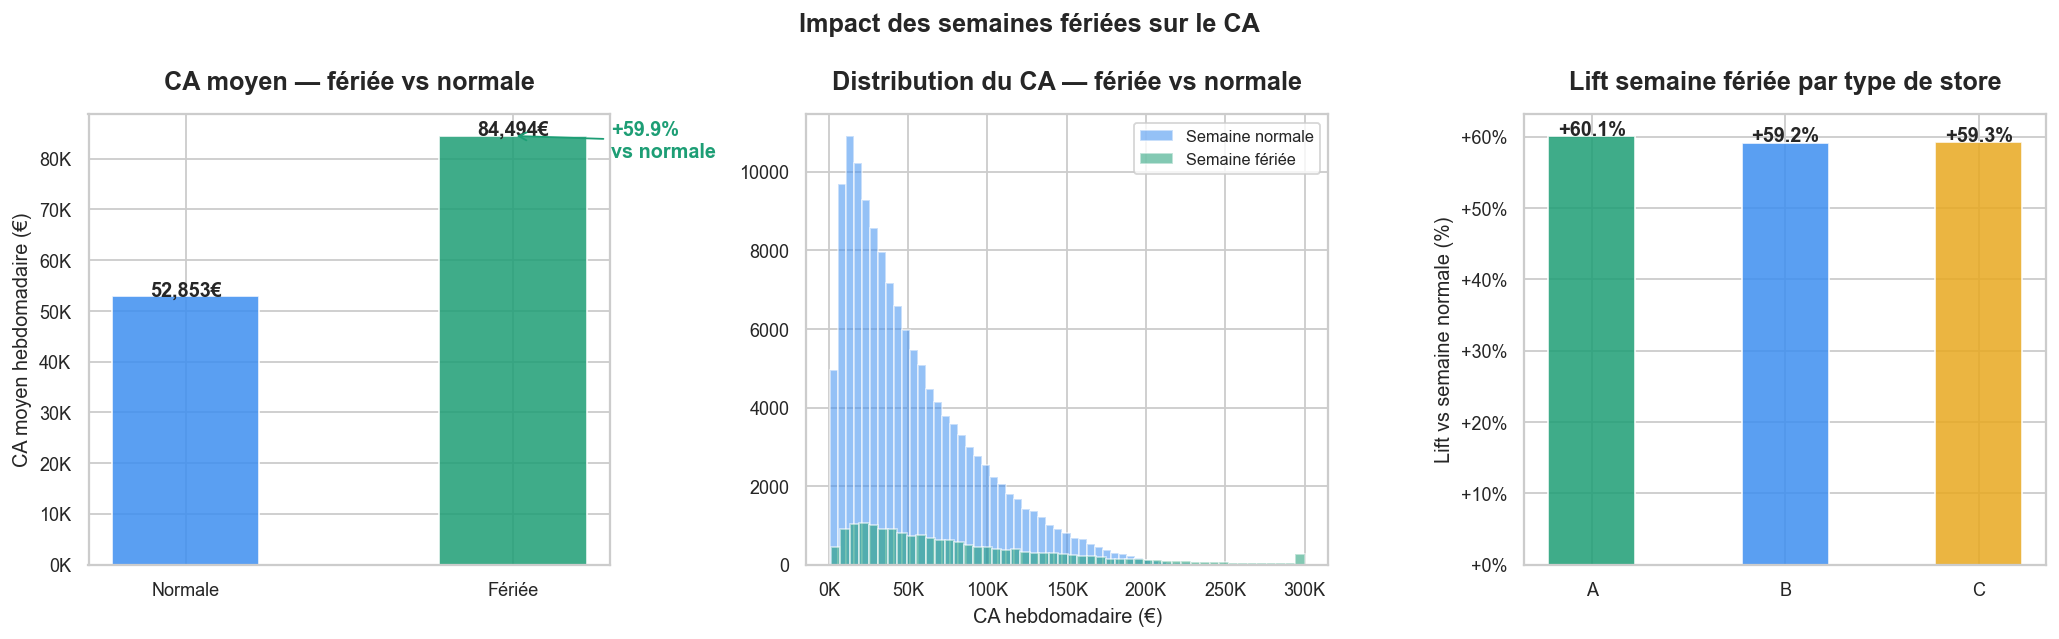


 Lift semaine fériée : +59.9% vs semaine normale


,holidaylabel,mean,median,std,count
0,Semaine fériée,84493.825439,64985.855,70008.418493,18000
1,Semaine normale,52852.575328,41406.465,41381.510831,138000


In [11]:
# CA moyen — fériées vs normales
holiday_stats = (
    df.groupby("holidaylabel")["weeklysalesclean"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

ca_normal = holiday_stats.loc[
    holiday_stats["holidaylabel"] == "Semaine normale", "mean"
].values[0]
ca_feriee = holiday_stats.loc[
    holiday_stats["holidaylabel"] == "Semaine fériée", "mean"
].values[0]
lift_pct = (ca_feriee - ca_normal) / ca_normal * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Barres comparaison
bars = axes[0].bar(
    ["Normale", "Fériée"],
    [ca_normal, ca_feriee],
    color=[COLOR_B, COLOR_A],
    alpha=0.85,
    edgecolor="white",
    width=0.45,
)
for bar, val in zip(bars, [ca_normal, ca_feriee]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,.0f}€",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )
axes[0].set_title("CA moyen — fériée vs normale")
axes[0].set_ylabel("CA moyen hebdomadaire (€)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y / 1000)}K"))

# Annotation lift
axes[0].annotate(
    f"+{lift_pct:.1f}%\nvs normale",
    xy=(1, ca_feriee),
    xytext=(1.3, ca_feriee * 0.95),
    arrowprops=dict(arrowstyle="->", color=COLOR_A),
    fontsize=11,
    fontweight="bold",
    color=COLOR_A,
)

# Distribution comparative
for label, color in [("Semaine normale", COLOR_B), ("Semaine fériée", COLOR_A)]:
    subset = df[df["holidaylabel"] == label]["weeklysalesclean"].clip(0, 300_000)
    axes[1].hist(
        subset, bins=50, alpha=0.55, color=color, label=label, edgecolor="white"
    )
axes[1].set_title("Distribution du CA — fériée vs normale")
axes[1].set_xlabel("CA hebdomadaire (€)")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x / 1000)}K"))
axes[1].legend(fontsize=9)

# Lift par type de store
lift_type = (
    df.groupby(["storetype", "holidaylabel"])["weeklysalesclean"]
    .mean()
    .unstack("holidaylabel")
    .assign(
        lift=lambda x: (
            (x["Semaine fériée"] - x["Semaine normale"]) / x["Semaine normale"] * 100
        )
    )
    .reset_index()
)

bars = axes[2].bar(
    lift_type["storetype"],
    lift_type["lift"],
    color=[COLORS_TYPE.get(t, COLOR_B) for t in lift_type["storetype"]],
    alpha=0.85,
    edgecolor="white",
    width=0.45,
)
for bar, val in zip(bars, lift_type["lift"]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"+{val:.1f}%",
        ha="center",
        fontweight="bold",
        fontsize=11,
    )
axes[2].set_title("Lift semaine fériée par type de store")
axes[2].set_ylabel("Lift vs semaine normale (%)")
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"+{y:.0f}%"))

plt.suptitle("Impact des semaines fériées sur le CA", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("05_impact_holidays.png")
plt.show()

print(f"\n Lift semaine fériée : +{lift_pct:.1f}% vs semaine normale")
display(holiday_stats)

In [12]:
# Détail par événement (Super Bowl, Labor Day, Thanksgiving, Christmas)
holiday_events = {
    "Super Bowl": ["2010-02-12", "2011-02-11", "2012-02-10"],
    "Labor Day": ["2010-09-10", "2011-09-09", "2012-09-07"],
    "Thanksgiving": ["2010-11-26", "2011-11-25"],
    "Christmas": ["2010-12-31", "2011-12-30"],
}

event_stats = []
for event, dates in holiday_events.items():
    mask = df["date"].isin(pd.to_datetime(dates))
    ca_event = df[mask]["weeklysalesclean"].mean() if mask.sum() > 0 else np.nan
    lift = (
        (ca_event - ca_normal) / ca_normal * 100 if not np.isnan(ca_event) else np.nan
    )
    event_stats.append(
        {"Événement": event, "CA moyen": ca_event, "Lift vs normale (%)": lift}
    )

event_df = pd.DataFrame(event_stats).round(2)
print("\n Performance par événement fériée :")
display(event_df)

event_df.to_csv(os.path.join(TABLES, "impact_holidays.csv"), index=False)
print(" Exporté → outputs/tables/impact_holidays.csv")


 Performance par événement fériée :


,Événement,CA moyen,Lift vs normale (%)
0,Super Bowl,NaN,NaN
1,Labor Day,NaN,NaN
2,Thanksgiving,NaN,NaN
3,Christmas,NaN,NaN


 Exporté → outputs/tables/impact_holidays.csv


---
## Impact des MarkDowns promotionnels

> Les promotions (MarkDown1-5) ont-elles un impact mesurable sur les ventes ?

In [ ]:
# # Analyse individuelle de chaque MarkDown
# md_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
# md_corrs = []
# for col in md_cols:
#     if col in df.columns:
#         subset = df[df[col] > 0]
#         corr = subset[[col, "Weekly_Sales_Clean"]].corr().iloc[0, 1]
#         md_corrs.append(
#             {
#                 "MarkDown": col,
#                 "Corrélation vs CA": round(corr, 4),
#                 "Nb semaines actives": len(subset),
#                 "Montant moyen": round(subset[col].mean(), 2),
#             }
#         )

# md_corr_df = pd.DataFrame(md_corrs).sort_values("Corrélation vs CA", ascending=False)

# fig, ax = plt.subplots(figsize=(10, 4))
# colors = [COLOR_A if v > 0 else COLOR_NEG for v in md_corr_df["Corrélation vs CA"]]
# bars = ax.bar(
#     md_corr_df["MarkDown"],
#     md_corr_df["Corrélation vs CA"],
#     color=colors,
#     alpha=0.85,
#     edgecolor="white",
#     width=0.5,
# )
# for bar, val in zip(bars, md_corr_df["Corrélation vs CA"]):
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height() + (0.002 if val >= 0 else -0.008),
#         f"{val:.3f}",
#         ha="center",
#         fontsize=10,
#         fontweight="bold",
#     )
# ax.axhline(0, color="gray", linewidth=1)
# ax.set_title("Corrélation de chaque MarkDown avec le CA hebdomadaire")
# ax.set_ylabel("Corrélation de Pearson")
# plt.tight_layout()
# save_fig("07_correlation_markdowns.png")
# plt.show()

# print("\n📋 Détail par MarkDown :")
# display(md_corr_df)
# md_corr_df.to_csv(os.path.join(TABLES, "markdown_correlation.csv"), index=False)
# print(" Exporté → outputs/tables/markdown_correlation.csv")

---
## Performance par store — Segmentation des magasins

In [28]:
df.head()

,storeid,deptid,date,weeklysales,isholiday,storetype,storesize,region,temperature,fuelprice,...,year,month,week,quarter,monthname,dayname,sizecategory,totalmarkdown,hasmarkdown,markdownsegment
0,1,1,2022-01-01,119075.96,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
1,1,2,2022-01-01,119107.85,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
2,1,3,2022-01-01,84369.88,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
3,1,4,2022-01-01,88445.24,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
4,1,5,2022-01-01,65159.85,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte


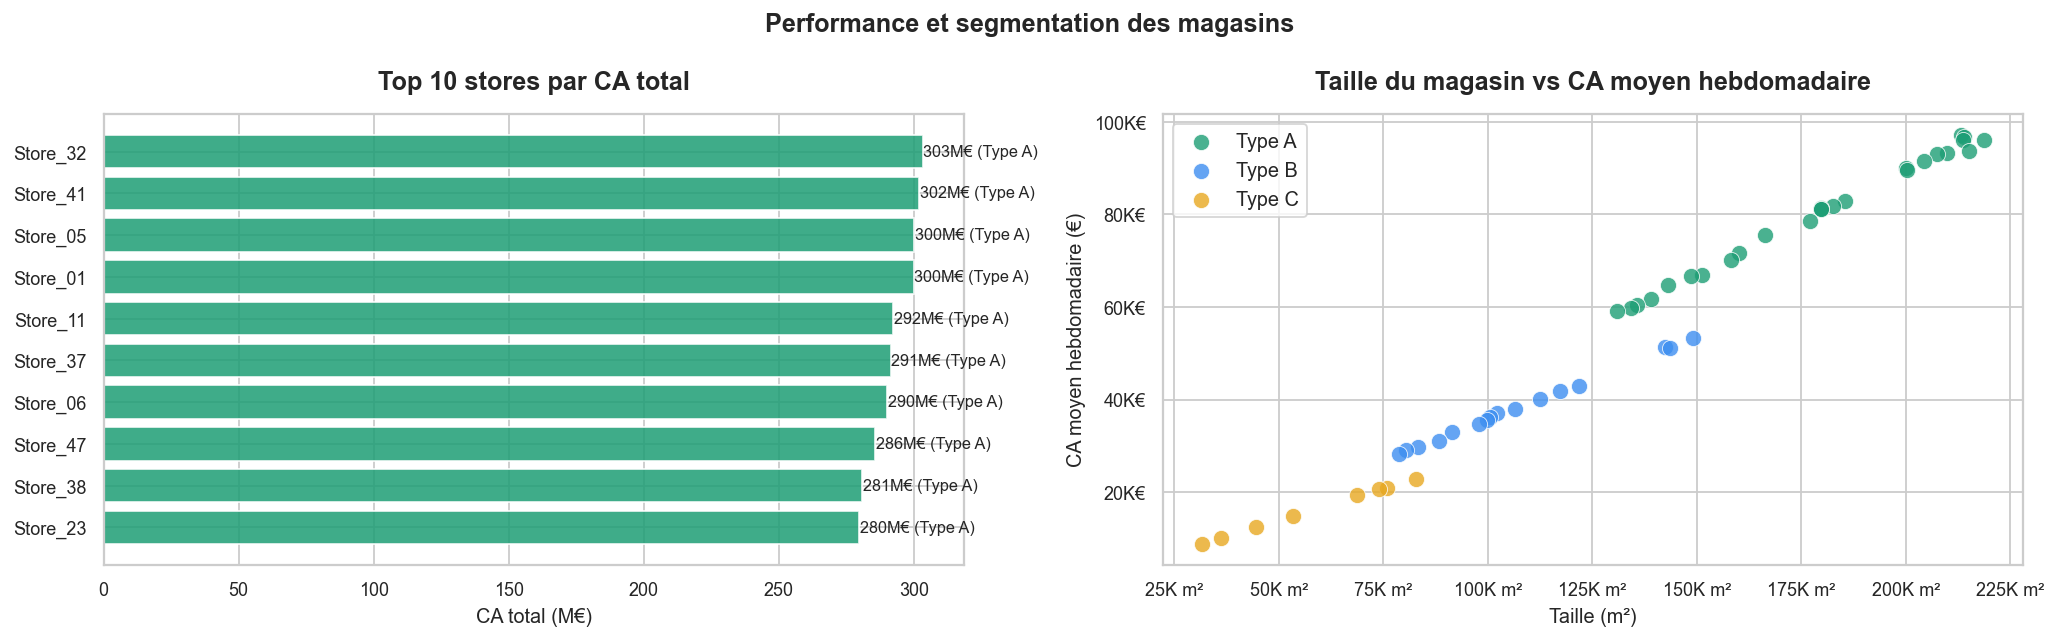

 Exporté → outputs/tables/store_performance.csv


,storeid,storelabel,storetype,storesize,sizecategory,catotal,camoyen,nbsemaines,nbdepts,perfrank,perfsegment
711587,32,Store_32,A,213320,Large,3.032230e+08,97186.874824,156,20,1.0,Top performer
918143,41,Store_41,A,213886,Large,3.018119e+08,96734.567692,156,20,2.0,Top performer
91949,5,Store_05,A,218696,Large,3.000639e+08,96174.319548,156,20,3.0,Top performer
140,1,Store_01,A,213810,Large,2.999050e+08,96123.396051,156,20,4.0,Top performer
229646,11,Store_11,A,215181,Large,2.923540e+08,93703.213080,156,20,5.0,Top performer
826334,37,Store_37,A,209840,Large,2.913743e+08,93389.211147,156,20,6.0,Top performer
114881,6,Store_06,A,207397,Large,2.901179e+08,92986.518862,156,20,7.0,Top performer
1055828,47,Store_47,A,204341,Large,2.857667e+08,91591.884330,156,20,8.0,Top performer
849272,38,Store_38,A,200010,Large,2.807494e+08,89983.776311,156,20,9.0,Top performer
505025,23,Store_23,A,200284,Large,2.796390e+08,89627.896346,156,20,10.0,Top performer


In [ ]:
# CA total et moyen par store
store_perf = (
    df.groupby(["storeid", "storelabel", "storetype", "storesize", "sizecategory"])
    .agg(
        catotal=("weeklysalesclean", "sum"),
        camoyen=("weeklysalesclean", "mean"),
        nbsemaines=("date", "nunique"),
        nbdepts=("deptid", "nunique"),
    )
    .reset_index()
    .sort_values("catotal", ascending=False)
)

# Segmentation performance (NTILE 3)
store_perf["perfrank"] = store_perf["catotal"].rank(ascending=False)
n = len(store_perf)
store_perf["perfsegment"] = pd.cut(
    store_perf["perfrank"],
    bins=[0, n // 3, 2 * n // 3, n + 1],
    labels=["Top performer", "Mid performer", "Low performer"],
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 10 stores
top10 = store_perf.head(10)
bar_colors = [COLORS_TYPE.get(t, COLOR_B) for t in top10["storetype"]]
bars = axes[0].barh(
    top10["storelabel"][::-1],
    top10["catotal"][::-1] / 1e6,
    color=bar_colors[::-1],
    alpha=0.85,
    edgecolor="white",
)
for bar, (_, row) in zip(bars, top10[::-1].iterrows()):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{row['catotal'] / 1e6:.0f}M€ (Type {row['storetype']})",
        va="center",
        fontsize=9,
    )
axes[0].set_title("Top 10 stores par CA total")
axes[0].set_xlabel("CA total (M€)")

# Scatter Size vs CA moyen coloré par Type
for t, color in COLORS_TYPE.items():
    subset = store_perf[store_perf["storetype"] == t]
    axes[1].scatter(
        subset["storesize"],
        subset["camoyen"],
        color=color,
        alpha=0.8,
        s=80,
        label=f"Type {t}",
        edgecolors="white",
        linewidth=0.5,
    )
axes[1].set_title("Taille du magasin vs CA moyen hebdomadaire")
axes[1].set_xlabel("Taille (m²)")
axes[1].set_ylabel("CA moyen hebdomadaire (€)")
axes[1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x / 1000)}K m²")
)
axes[1].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda y, _: f"{int(y / 1000)}K€")
)
axes[1].legend()

plt.suptitle("Performance et segmentation des magasins", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("08_performance_stores.png")
plt.show()

store_perf.to_csv(os.path.join(TABLES, "store_performance.csv"), index=False)
print(" Exporté → outputs/tables/store_performance.csv")
display(store_perf.head(10))

---
## Analyse des départements

In [24]:
df.head()

,storeid,deptid,date,weeklysales,isholiday,storetype,storesize,region,temperature,fuelprice,...,year,month,week,quarter,monthname,dayname,sizecategory,totalmarkdown,hasmarkdown,markdownsegment
0,1,1,2022-01-01,119075.96,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
1,1,2,2022-01-01,119107.85,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
2,1,3,2022-01-01,84369.88,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
3,1,4,2022-01-01,88445.24,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte
4,1,5,2022-01-01,65159.85,1,A,213810,North,97.57,4.83,...,2022,1,52,1,January,Saturday,Large,29476.38,1,Promo forte


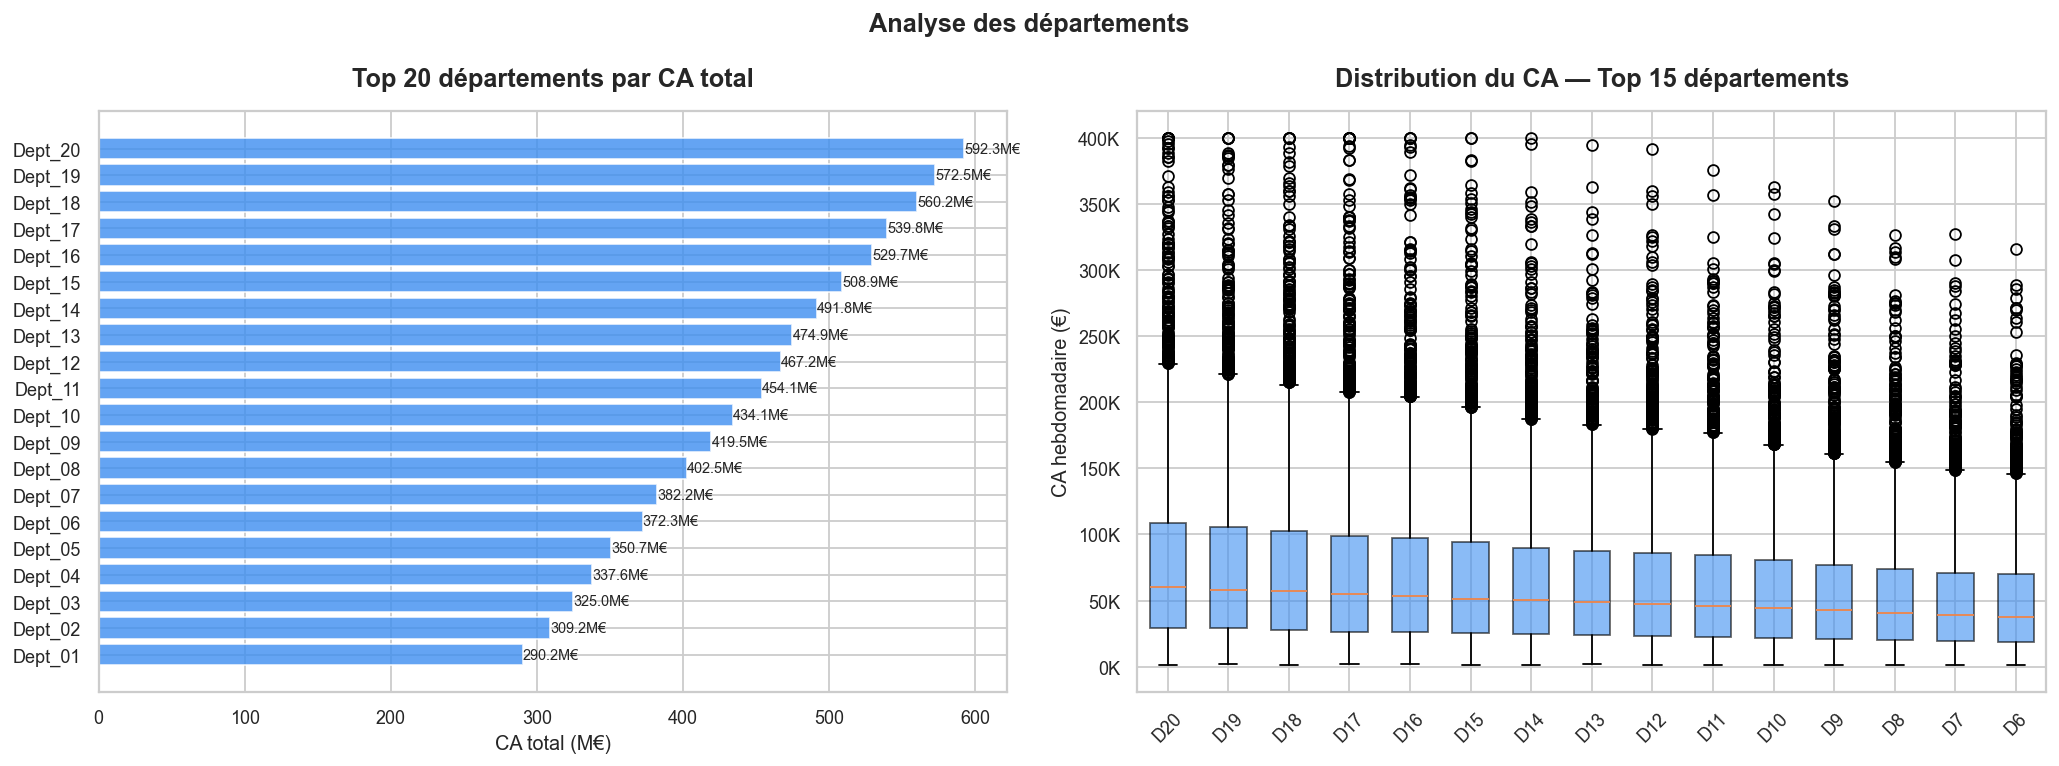

 Exporté → outputs/tables/dept_performance.csv


In [36]:
# Top 20 départements
dept_perf = (
    df.groupby(["deptid", "deptlabel"])
    .agg(
        catotal=("weeklysalesclean", "sum"),
        camoyen=("weeklysalesclean", "mean"),
        nbstores=("storeid", "nunique"),
    )
    .reset_index()
    .sort_values("catotal", ascending=False)
)

top20_dept = dept_perf.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 CA total
bars = axes[0].barh(
    top20_dept["deptlabel"][::-1],
    top20_dept["catotal"][::-1] / 1e6,
    color=COLOR_B,
    alpha=0.8,
    edgecolor="white",
)
for bar, val in zip(bars, top20_dept["catotal"][::-1]):
    axes[0].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val / 1e6:.1f}M€",
        va="center",
        fontsize=8,
    )
axes[0].set_title("Top 20 départements par CA total")
axes[0].set_xlabel("CA total (M€)")

# Distribution CA par département (boxplot des 15 meilleurs)
top15_depts = dept_perf.head(15)["deptid"].tolist()
df_top15 = df[df["deptid"].isin(top15_depts)]
dept_order = (
    df_top15.groupby("deptid")["weeklysalesclean"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data_box2 = [
    df_top15[df_top15["deptid"] == d]["weeklysalesclean"].clip(0, 400_000)
    for d in dept_order
]
bp = axes[1].boxplot(
    data_box2, patch_artist=True, labels=[f"D{d}" for d in dept_order], widths=0.6
)
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_B)
    patch.set_alpha(0.6)
axes[1].set_title("Distribution du CA — Top 15 départements")
axes[1].set_ylabel("CA hebdomadaire (€)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, _: f"{int(y / 1000)}K"))
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Analyse des départements", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("09_performance_depts.png")
plt.show()

dept_perf.to_csv(os.path.join(TABLES, "dept_performance.csv"), index=False)
print(" Exporté → outputs/tables/dept_performance.csv")

---
## Heatmap Store × Mois

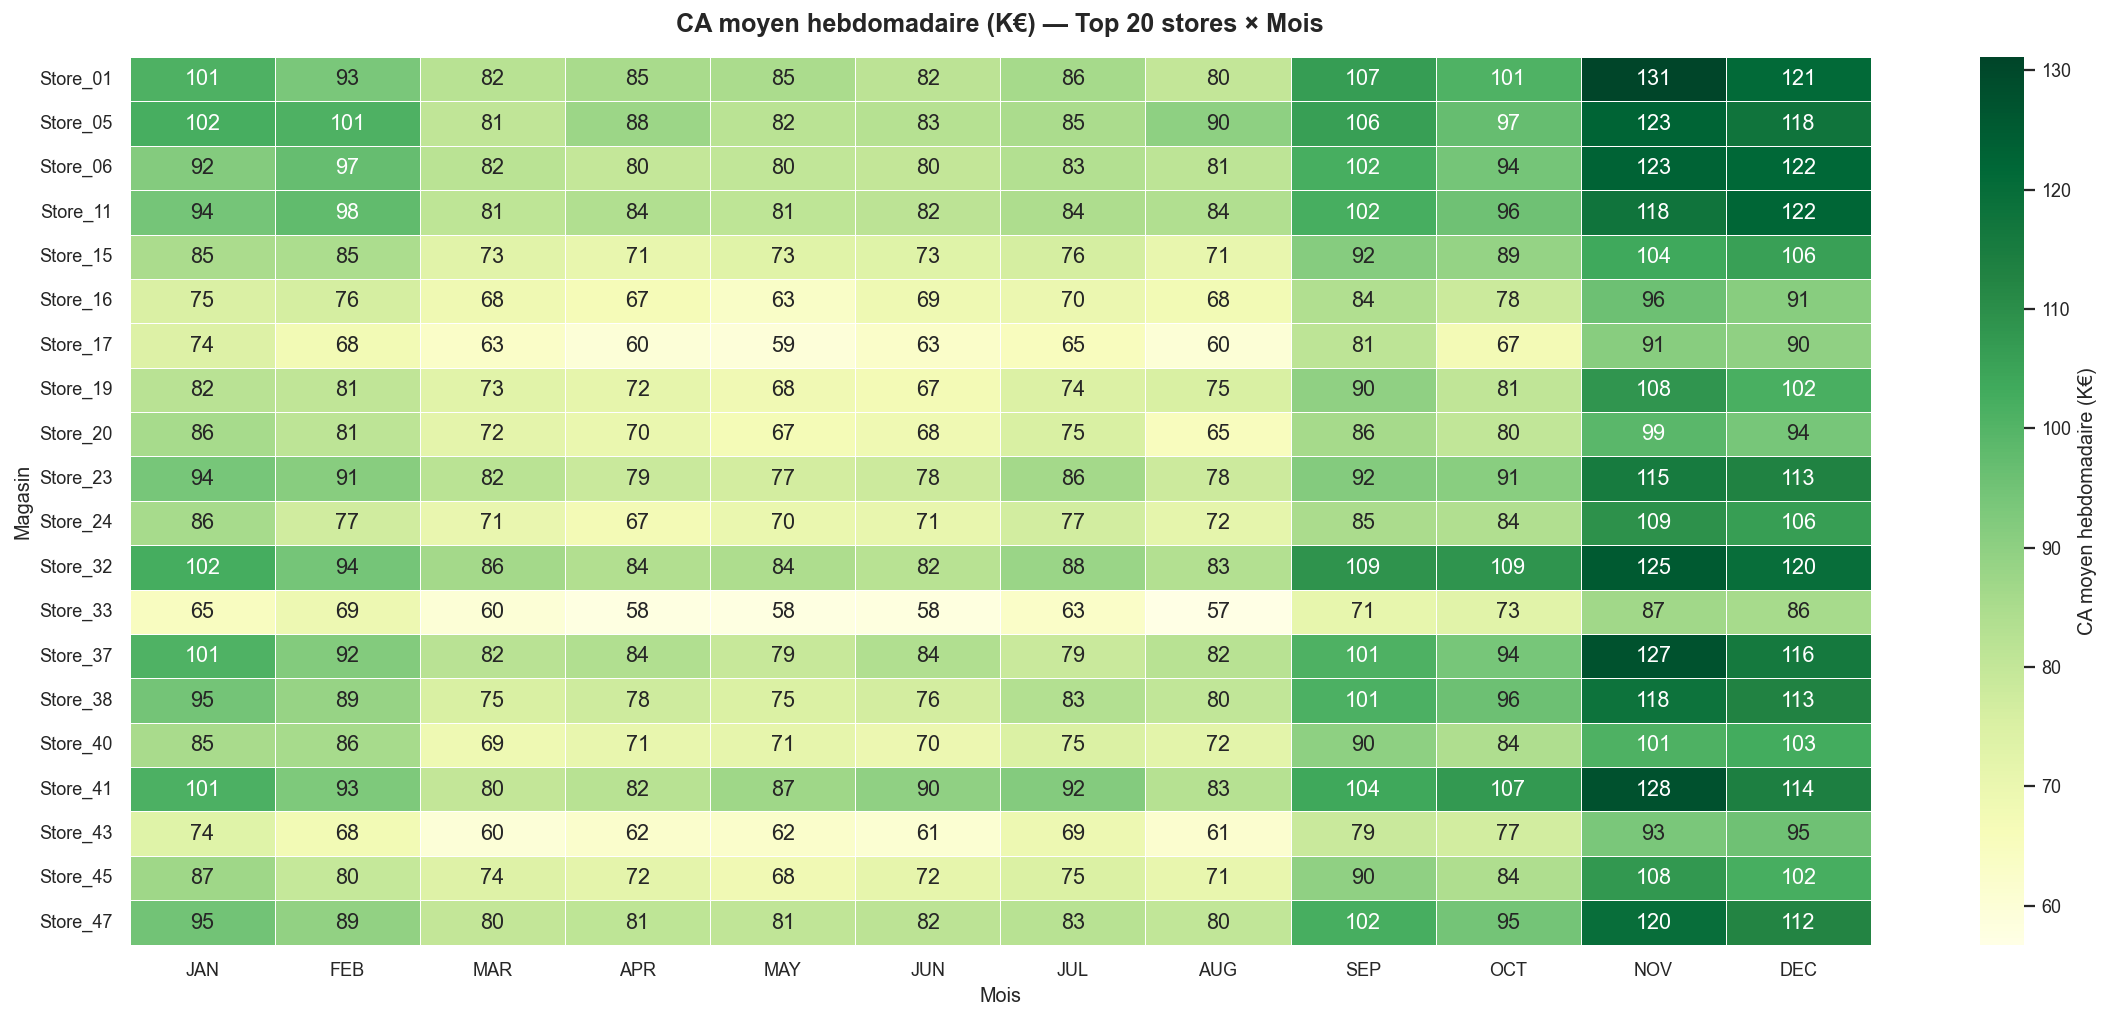

 Les cases les plus foncées = store + mois à fort potentiel


In [37]:
# Heatmap CA moyen : Store (top 20) × Mois
top20_stores = store_perf.head(20)["storeid"].tolist()
heatmap_data = (
    df[df["storeid"].isin(top20_stores)]
    .groupby(["storelabel", "monthname"], observed=True)["weeklysalesclean"]
    .mean()
    .unstack("monthname")
    .reindex(columns=[m for m in MONTH_ORDER if m in df["monthname"].cat.categories])
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    heatmap_data / 1000,
    annot=True,
    fmt=".0f",
    cmap="YlGn",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "CA moyen hebdomadaire (K€)"},
    ax=ax,
)
ax.set_title("CA moyen hebdomadaire (K€) — Top 20 stores × Mois", pad=14)
ax.set_xlabel("Mois")
ax.set_ylabel("Magasin")
ax.set_xticklabels([m[:3].upper() for m in heatmap_data.columns], rotation=0)
plt.tight_layout()
save_fig("10_heatmap_store_mois.png")
plt.show()
print(" Les cases les plus foncées = store + mois à fort potentiel")

---
## Matrice de corrélation — Variables macro-économiques

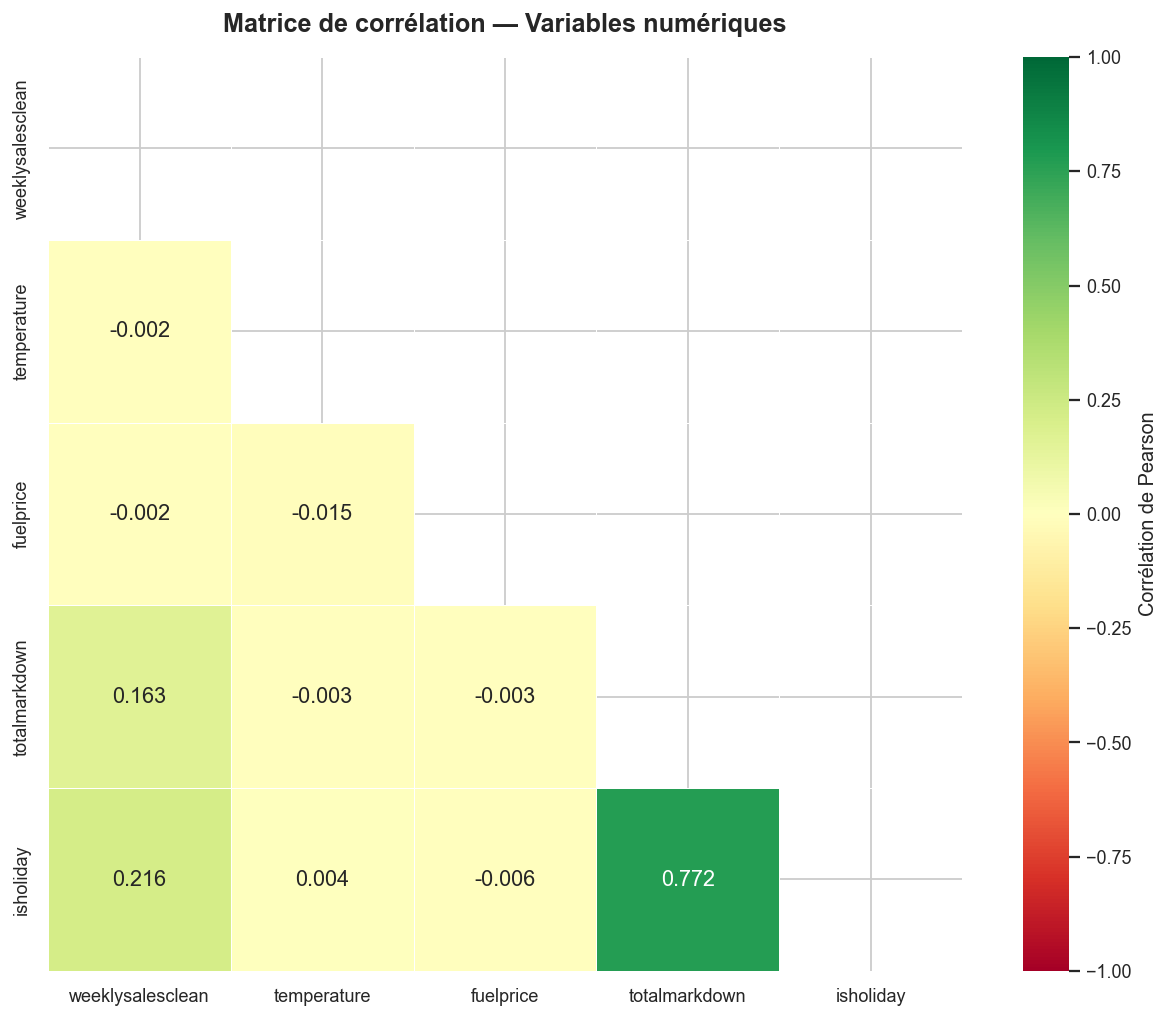


 Variables les plus corrélées avec weeklysalesclean :
isholiday        0.216385
totalmarkdown    0.163314
fuelprice       -0.002101
temperature     -0.001684


In [39]:
num_cols = [
    "weeklysalesclean",
    "temperature",
    "fuelprice",
    "CPI",
    "Unemployment",
    "totalmarkdown",
    "isholiday",
]
num_cols_present = [c for c in num_cols if c in df.columns]

corr = df[num_cols_present].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    cbar_kws={"label": "Corrélation de Pearson"},
)
ax.set_title("Matrice de corrélation — Variables numériques", pad=14)
plt.tight_layout()
save_fig("11_correlation_matrix.png")
plt.show()

print("\n Variables les plus corrélées avec weeklysalesclean :")
print(
    corr["weeklysalesclean"]
    .drop("weeklysalesclean")
    .sort_values(key=abs, ascending=False)
    .to_string()
)

---
## Synthèse des insights

In [ ]:
best_type = df.groupby("storetype")["weeklysalesclean"].mean().idxmax()
best_month = ca_month_avg.loc[ca_month_avg["weeklysalesclean"].idxmax(), "monthname"]
top_store = store_perf.iloc[0]["storelabel"]
top_dept = dept_perf.iloc[0]["deptlabel"]
# best_md = md_corr_df.iloc[0]["MarkDown"]


print("   SYNTHÈSE INSIGHTS — PARTIE 2")

insights = [
    (
        "Type de store le plus performant",
        f"Type {best_type} — CA moyen {df[df['storetype'] == best_type]['weeklysalesclean'].mean():,.0f}€/sem",
    ),
    (
        "Meilleur mois",
        f"{best_month} — {ca_month_avg.loc[ca_month_avg['monthname'] == best_month, 'weeklysalesclean'].values[0]:,.0f}€ moyen",
    ),
    ("Lift semaine fériée", f"+{lift_pct:.1f}% vs semaine normale"),
    # ("Lift avec MarkDown", f"+{lift_md:.1f}% vs sans promotion"),
    #
    # (
    #     # "MarkDown le plus corrélé au CA",
    #     # f"{best_md} (r={md_corr_df.iloc[0]['Corrélation vs CA']:.3f})",
    # ),
    ("Store le plus performant", f"{top_store}"),
    ("Département le plus performant", f"{top_dept}"),
]
for label, value in insights:
    print(f"   {label:<42} → {value}")

# Export synthèse
pd.DataFrame(insights, columns=["Insight", "Valeur"]).to_csv(
    os.path.join(TABLES, "synthese_insights.csv"), index=False
)
print("\n Synthèse exportée → outputs/tables/synthese_insights.csv")
print("\n Prochaine étape : Partie 3 — Analyses SQL avancées")

   SYNTHÈSE INSIGHTS — PARTIE 2
   Type de store le plus performant           → Type A — CA moyen 80,067€/sem
   Meilleur mois                              → November — 73,302€ moyen
   Lift semaine fériée                        → +59.9% vs semaine normale
   Store le plus performant                   → Store_32
   Département le plus performant             → Dept_20

 Synthèse exportée → outputs/tables/synthese_insights.csv

 Prochaine étape : Partie 3 — Analyses SQL avancées
